# Blazar Population ML – Part 2: Baryon Loading Regression (MOJAVE Cross-Match)

**Table of Content**

12. [Introduction – Part 2](#12-introduction)
13. Setup and imports
14. EDA – Part 2
15. Regression Setup
<!-- Load and inspect 4LAC-DR3
20. Conclusion - Part 2 -->

## 12. Introduction

### About this Project – Part 2

[Part 1](./blazar_population_ml-p1.ipynb) established the cluster geometry of the full 4LAC-DR3 blazar population and assigned probabilistic classifications to BCU sources using unsupervised methods. Part 2 (this notebook) shifts to the supervised regression task: given the 334-source MOJAVE-matched subsample, can a model recover the baryon loading constraint $50 \lesssim \mu \lesssim 80$ derived by Rueda-Becerril, Harrison & Giannios (2021, RHG21 hereafter) from purely observational features?

The feature set expands beyond [Part 1](./blazar_population_ml-p1.ipynb). Appended kinematic observables $\beta_{\rm app}$ and $\Gamma_{\rm min} = \sqrt{1 + \beta_{\rm app}^2}$ from MOJAVE-XVII (Lister et al. 2021) are the same quantities used in the forward model of the 2021 paper. This is the direct observational link between the simulation constraints and the data-driven approach.

In this notebook we address the second part of the project. Using the numerical code [`Paramo`](https://github.com/altjerue/paramo) to solve the Fokker-Planck equation for the evolving electron distribution and compute synchrotron, SSC, and EC emission, the authors generate synthetic SEDs across a grid of magnetization values and compare them to observational data from Ghisellini et al. (2011) for the $\gamma$-ray spectral properties, Lister et al. (2019) for MOJAVE apparent velocities, and Finke (2013) for $A_C$. The **entire blazar sequence is recovered qualitatively for models with mild baryon loading $50 \lesssim \mu \lesssim 80$**. Jets with $\mu < 50$ are inconsistent with the Lorentz factors inferred from VLBI for highly magnetized cases, and jets with $\mu > 80$ exceed observed apparent velocities. This narrow range constrains the energy per baryon of blazar jets independently of their accretion rate, providing the first simple physical model capable of accounting for the whole blazar population.

**Scientific question:** Does a Gaussian Process Regression model trained on $\{\log \nu_{\rm syn},\, A_C,\, \Gamma_{\rm min},\, \ldots\}$ recover a $\mu$ distribution consistent with $\mu \in [50, 80]$ across the MOJAVE subsample? The agreement of an independent method would validate results in RHG21 in a fully data-driven setting. Disagreement is as well informative for it will constrain which features carry the baryon loading signal and where RHG21 model assumptions break down.

### Baryon Loading and Jet Composition

The physical composition of relativistic jets is a fundamental unsolved problem in high-energy astrophysics. Whether jets are dominated by electron-positron pairs or carry a significant hadronic component determines their total kinetic power and efficiency as particle accelerators, but this hadronic content cannot be measured directly. It must be inferred through a combination of radiative modeling and kinematic observations.

The key parameter is the **baryon loading** $\mu$, defined as the total energy flux per unit rest-mass energy flux of the jet (e.g., Komissarov et al. 2007):

$$\mu := \Gamma(1 + \sigma)$$

where $\Gamma$ is the bulk Lorentz factor and $\sigma$ is the jet magnetization, defined as the ratio of Poynting flux to hydrodynamic energy flux. A jet with $\mu \approx 1$ would be nearly magnetically dominated, while larger $\mu$ means more energy per baryon is available for acceleration and radiation. According to magnetohydrodynamic (MHD) theory, $\mu$ is conserved along the jet during magnetic acceleration: as $\Gamma$ increases, $\sigma$ decreases proportionally, leaving $\mu$ imprinted by the launch conditions near the black hole. Constraining $\mu$ from observations is therefore a direct probe of the jet formation mechanism.

In RHG21, the authors propose and test a simple physical picture: all blazar jets are launched with similar energy per baryon, that is, $\mu$ is approximately constant across the entire blazar population regardless of jet power or accretion rate. The accretion rate $\dot{m}$ (in Eddington units) connects the bulk Lorentz factor and the jet luminosity through an empirical power-law relation motivated by VLBI observations ($\dot{m} \propto \Gamma^s$), effectively parameterizing the full SED by a single observable. Within this framework:

- **FSRQs** correspond to high $\dot{m}$. Their jets achieve large $\Gamma$ but settle at low magnetization ($\sigma \lesssim 10$) at the emission region. Magnetic reconnection injects a steep particle energy distribution ($p \gtrsim 2$), producing soft $\gamma$-ray spectra. The dense external photon field from the BLR drives EC emission, pushing Compton dominance to values well above unity and $\nu_{\rm syn}$ to low frequencies.
- **BL Lacs** correspond to low $\dot{m}$. Their jets do not reach large $\Gamma$, leaving the emission region more strongly magnetized ($\sigma \gtrsim 10$). Reconnection produces a hard particle spectrum ($p \lesssim 2$) and hard $\gamma$-ray emission at $\gtrsim$ GeV. The faint or absent BLR means SSC dominates, keeping $\nu_{\rm syn}$ at high frequencies and Compton dominance near or below unity.

## 13. Setup and Imports

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

# Paths
DATA_DIR = Path("data/")
LAC_H = DATA_DIR / "table-4LAC-DR3-h.fits"
MOJAVE = DATA_DIR / "VizieR-MOJAVE-XVII.fit"

# Plot style
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
CLASS_COLORS = {"bll": "steelblue", "fsrq": "tomato", "bcu": "green"}
SED_COLORS = {"lsp": "tomato", "isp": "goldenrod", "hsp": "steelblue"}

In [22]:
# Load Part 2 parquet
matched_df = pd.read_parquet("data/part2_4lac_mojave.parquet")
print(matched_df.info())
matched_df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_name      334 non-null    str    
 1   mojave_id        334 non-null    str    
 2   class            334 non-null    str    
 3   sed_class        334 non-null    str    
 4   redshift         301 non-null    float64
 5   pl_index         334 non-null    float64
 6   lp_alpha         334 non-null    float64
 7   lp_beta          334 non-null    float64
 8   log_nu_syn       327 non-null    float64
 9   log_nuFnu_syn    327 non-null    float64
 10  log_he_epeak     318 non-null    float64
 11  log_compton_dom  312 non-null    float64
 12  log_gamma_lum    301 non-null    float64
 13  var_index        334 non-null    float64
 14  frac_var         320 non-null    float64
 15  beta_app         334 non-null    float64
 16  e_beta           334 non-null    float64
 17  gamma_min        334 non-nu

,redshift,pl_index,lp_alpha,lp_beta,log_nu_syn,log_nuFnu_syn,log_he_epeak,log_compton_dom,log_gamma_lum,var_index,frac_var,beta_app,e_beta,gamma_min,sep_arcsec
count,301.00,334.00,334.00,334.00,327.00,327.00,318.00,312.00,301.00,334.00,320.00,334.00,334.00,334.00,334.00
mean,0.93,2.33,2.26,0.10,13.10,-11.41,2.36,0.14,46.51,1508.43,0.68,7.92,0.82,8.27,0.01
std,0.64,0.23,0.25,0.09,0.80,0.47,0.86,0.49,1.14,6727.74,0.38,8.69,1.03,8.41,0.03
min,0.00,1.68,1.57,-0.11,11.32,-12.49,-0.51,-1.50,41.81,4.95,0.03,0.00,0.00,1.00,0.00
25%,0.42,2.19,2.11,0.06,12.62,-11.73,1.96,-0.20,45.95,55.33,0.41,0.22,0.05,1.02,0.01
50%,0.86,2.34,2.26,0.09,12.92,-11.46,2.30,0.09,46.72,264.32,0.60,5.34,0.52,5.43,0.01
75%,1.34,2.48,2.42,0.12,13.30,-11.13,2.76,0.47,47.25,900.23,0.89,12.56,1.10,12.60,0.02
max,3.10,2.90,3.03,1.00,16.34,-9.66,6.12,1.84,48.68,84340.76,2.29,41.50,7.30,41.51,0.54


In [23]:
print(f"\nCLASS breakdown:")
print(matched_df["class"].value_counts())

print(f'\nbeta_app = 0 sources: {(matched_df["beta_app"] == 0).sum()}')

print(f'\ngamma_min stats:\n{matched_df["gamma_min"].describe().round(2)}')


CLASS breakdown:
class
fsrq     200
bll      110
rdg        8
bcu        8
nlsy1      4
css        2
agn        1
ssrq       1
Name: count, dtype: int64

beta_app = 0 sources: 71

gamma_min stats:
count    334.00
mean       8.27
std        8.41
min        1.00
25%        1.02
50%        5.43
75%       12.60
max       41.51
Name: gamma_min, dtype: float64


## 14. Exploratory Data Analysis

The MOJAVE-XVII cross-match introduces a strong kinematic selection bias: MOJAVE targets bright, compact, flat-spectrum sources with high apparent velocities, which preferentially selects FSRQs and low-frequency-peaked BL Lacs over the HSP population. Before proceeding to regression, we characterize this bias explicitly. Since the GPR will be trained on this subsample, the generalizability of any recovered $\mu$ distribution depends directly on how representative the subsample is of the full blazar population.

We will examine here four diagnostics:

1. $\Gamma_{\rm min}$ distribution by CLASS: FSRQs are expected to dominate the high-$\Gamma_{\rm min}$ tail, reflecting the MOJAVE kinematic selection threshold.
2. $\beta_{\rm app}$ vs. $\log \nu_{\rm syn}$: the kinematic-SED anti-correlation expected from the blazar sequence and the RHG21 model.
3. Part 2 sources in the Part 1 UMAP embedding: whether the MOJAVE subsample occupies the full parameter space or is concentrated in the FSRQ/LSP region.
4. $\log \nu_{\rm syn}$ distribution, MOJAVE subsample vs. full 4LAC-DR3 complete-case catalog: the feature most sensitive to the FSRQ/BL Lac split and the primary observable linking the blazar sequence to the baryon loading constraint.

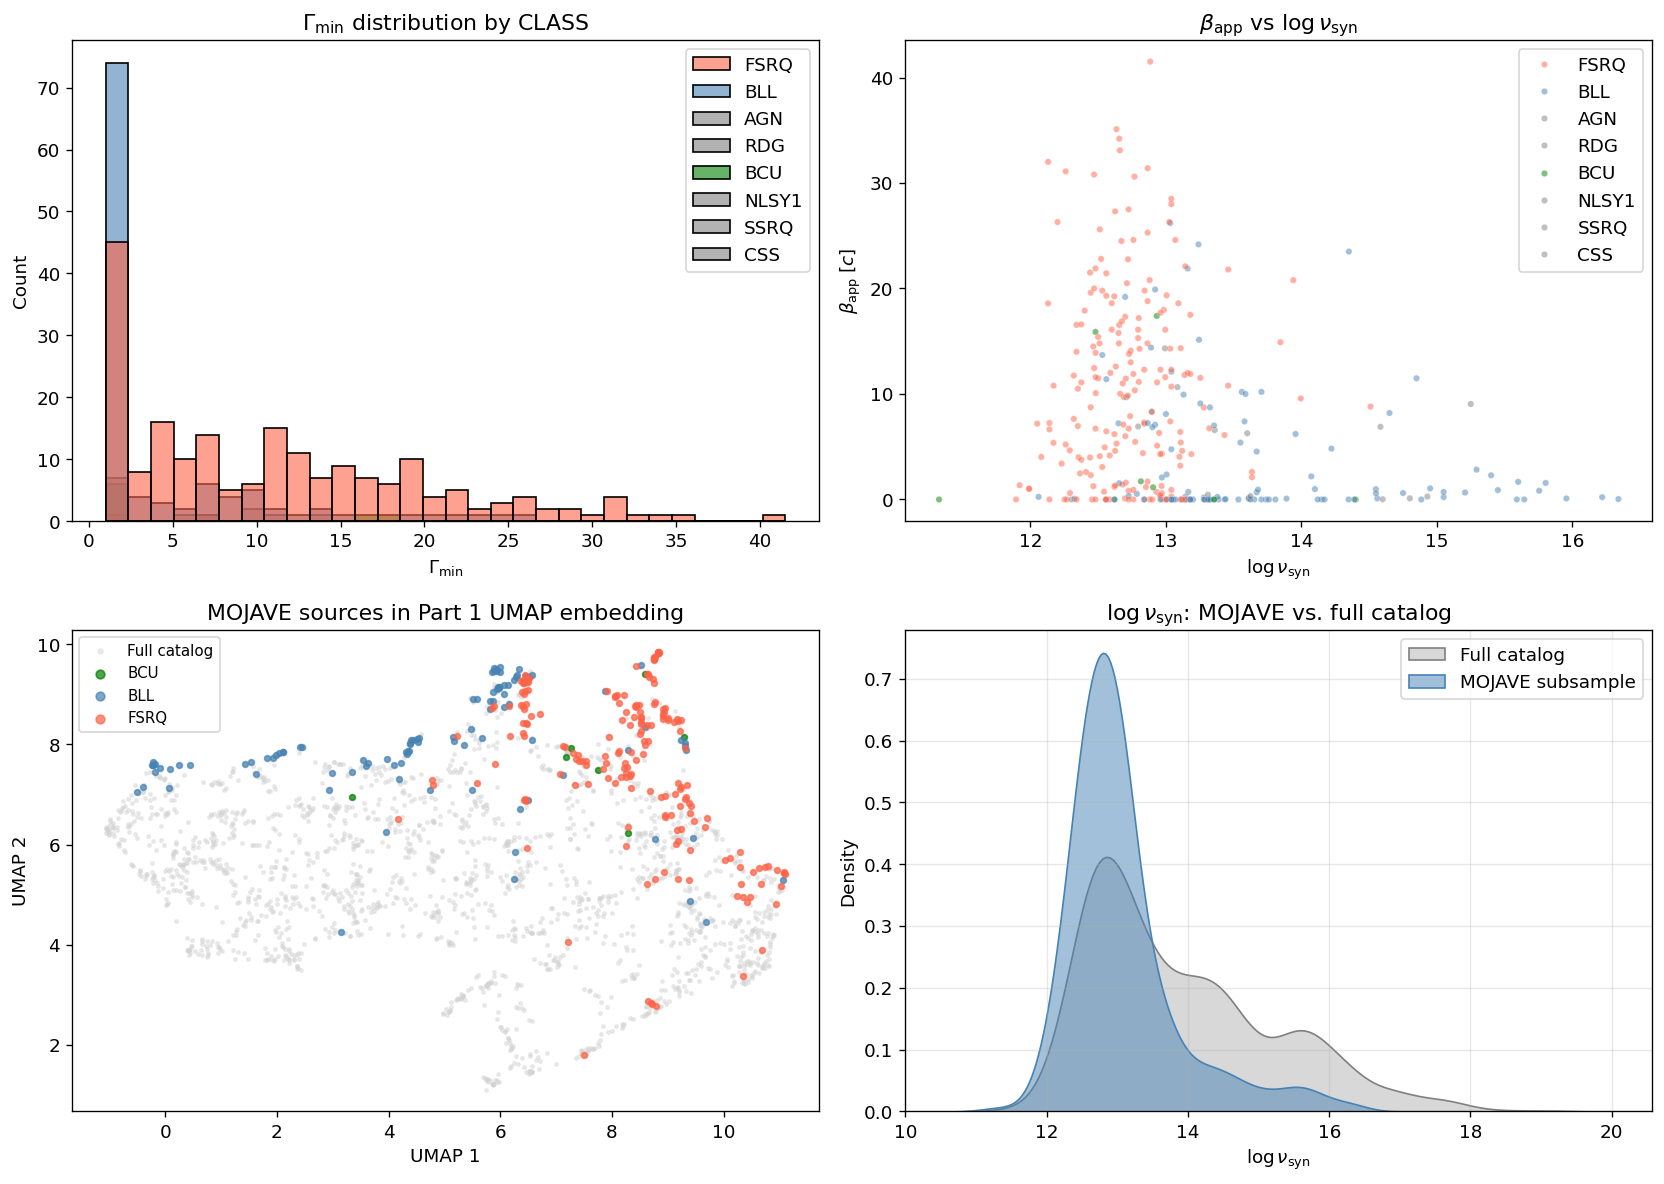

In [26]:
# Load pca_df for UMAP overlay and catalog-level KDE
pca_df = pd.read_parquet("data/pca_catalog.parquet")
pca_df["in_mojave"] = pca_df["source_name"].isin(matched_df["source_name"])
mojave_in_pca = pca_df[pca_df["in_mojave"]]

# Build full palette: known classes get CLASS_COLORS
_all_cls = matched_df["class"].unique()
_palette = {cls: CLASS_COLORS.get(cls, "gray") for cls in _all_cls}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. gamma_min by CLASS
ax = axes[0, 0]
sns.histplot(
    data=matched_df,
    x="gamma_min",
    hue="class",
    bins=30,
    alpha=0.6,
    multiple="layer",
    palette=_palette,
    ax=ax,
)
leg = ax.get_legend()
leg.set_title("")
for t in leg.get_texts():
    t.set_text(t.get_text().upper())
ax.set_xlabel(r"$\Gamma_{\rm min}$")
ax.set_ylabel("Count")
ax.set_title(r"$\Gamma_{\rm min}$ distribution by CLASS")

# 2. beta_app vs log_nu_syn
ax = axes[0, 1]
sns.scatterplot(
    data=matched_df,
    x="log_nu_syn",
    y="beta_app",
    hue="class",
    s=15,
    alpha=0.5,
    palette=_palette,
    ax=ax,
)
leg = ax.get_legend()
leg.set_title("")
for t in leg.get_texts():
    t.set_text(t.get_text().upper())
ax.set_xlabel(r"$\log \nu_{\rm syn}$")
ax.set_ylabel(r"$\beta_{\rm app}\;[c]$")
ax.set_title(r"$\beta_{\rm app}$ vs $\log\nu_{\rm syn}$")

# 3. UMAP overlay: full catalog + MOJAVE subsample
ax = axes[1, 0]
ax.scatter(
    pca_df["UMAP1"],
    pca_df["UMAP2"],
    c="lightgray",
    s=4,
    alpha=0.4,
    rasterized=True,
    label="Full catalog",
)
for cls, grp in mojave_in_pca.groupby("class"):
    ax.scatter(
        grp["UMAP1"],
        grp["UMAP2"],
        s=12,
        alpha=0.7,
        color=CLASS_COLORS.get(cls, "gray"),
        label=cls.upper(),
    )
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("MOJAVE sources in Part 1 UMAP embedding")
ax.legend(markerscale=1.5, fontsize=9)

# 4. log_nu_syn KDE: full catalog vs MOJAVE subsample
ax = axes[1, 1]
sns.kdeplot(
    data=pca_df,
    x="log_nu_syn",
    fill=True,
    alpha=0.3,
    color="gray",
    label="Full catalog",
    ax=ax,
)
sns.kdeplot(
    data=mojave_in_pca,
    x="log_nu_syn",
    fill=True,
    alpha=0.5,
    color="steelblue",
    label="MOJAVE subsample",
    ax=ax,
)
ax.set_xlabel(r"$\log \nu_{\rm syn}$")
ax.set_ylabel("Density")
ax.set_title(r"$\log \nu_{\rm syn}$: MOJAVE vs. full catalog")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The four diagnostics confirm a pronounced selection bias in the MOJAVE subsample. FSRQs dominate the high-$\Gamma_{\rm min}$ tail, as expected from MOJAVE's kinematic threshold: bright, fast-moving jets are preferentially associated with high-accretion-rate sources. The $\beta_{\rm app}$ vs. $\log \nu_{\rm syn}$ scatter reproduces the anti-correlation predicted by the blazar sequence and the RHG21 model, with FSRQs clustering at low $\log \nu_{\rm syn}$ and high apparent velocities, and BL Lacs at high $\log \nu_{\rm syn}$ and low $\beta_{\rm app}$.

The UMAP overlay makes the spatial extent of this bias explicit: the MOJAVE sources are heavily concentrated in the FSRQ/LSP region of the [Part 1](./blazar_population_ml-p1.ipynb) embedding and largely absent from the HSP BL Lac locus. The $\log \nu_{\rm syn}$ KDE reinforces this: while both distributions share a similar peak, the MOJAVE subsample is narrower and systematically underrepresents the high-$\log \nu_{\rm syn}$ tail where HSP BL Lacs reside.

We found in [Part 1](./blazar_population_ml-p1.ipynb) that out of the 334 MOJAVE-matched sources, 300 have complete-case PCA features and therefore appear in the UMAP embedding. The remaining 34 were dropped in Sec. 7 "Missingness Audit" in Part 1.

The consequence for regression is direct: the GPR will be trained on a sample that is roughly 60% FSRQs and undersamples the HSP BL Lac population by a large margin. Predictions for high-$\log \nu_{\rm syn}$ sources should be treated as extrapolations beyond the training distribution. This limitation does not invalidate the regression, but it must be stated explicitly when interpreting whether the recovered $\mu$ distribution generalizes to the full blazar population.

## 15. Regression Setup

### Target Variable

$\mu = \Gamma(1 + \sigma)$ is not directly observable. The 2021 paper shows that for a model grid consistent with blazar observables, $50 \lesssim \mu \lesssim 80$. This establishes the expected range but provides no per-source $\mu$ estimate.

The regression target encoding has two options:

**Option A (direct kinematic proxy):** Use $\Gamma_{\rm min}$ as the regression target. This is a measured quantity and is the observational proxy used in the 2021 paper. The question becomes: can SED features predict $\Gamma_{\rm min}$? If the blazar sequence encodes kinematic information at the population level (the small viewing-angle argument from Part 1), this should hold. This is the conservative, defensible choice.

**Option B (Tleco pseudo-labels):** Run Tleco over a grid of $(\mu, \sigma, \Gamma, \dot{m})$ and use the synthetic SED features as training data with $\mu$ as the label. Train on synthetic data, evaluate on observed. This tests the emulator assumption directly and is the more ambitious claim. Requires the Tleco data generation pipeline (Project 2 precursor).

**For this notebook, Option A is implemented.** Option B is documented as a forward reference to Project 2.

### Feature Set

Nine features: the seven SED features from Part 1 plus $\beta_{\rm app}$ and $\Gamma_{\rm min}$. Sources with $\beta_{\rm app} = 0$ are excluded from the regression (uninformative kinematic constraint). Sources missing any of the nine features are dropped (complete-case). Document the resulting sample size.

In [25]:
# Feature set for Part 2 regression
p2_feats = [
    "pl_index",
    "lp_alpha",
    "lp_beta",
    "log_nu_syn",
    "log_nuFnu_syn",
    "log_compton_dom",
    "var_index",
    "beta_app",
    "gamma_min",
]
TARGET = "gamma_min"

# Exclude betaMax=0 sources (uninformative kinematic constraint)
p2_reg = p2[p2["beta_app"] > 0].copy()
print(f'Removed {(p2["beta_app"] == 0).sum()} sources with beta_app=0')

# Complete-case filter
reg_mask = p2_reg[p2_feats].notna().all(axis=1)
p2_reg = p2_reg[reg_mask].reset_index(drop=True)
print(f"Regression sample (complete cases): {len(p2_reg)} sources")
print(f'CLASS breakdown:\n{p2_reg["class"].value_counts()}')

NameError: name 'p2' is not defined